In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import get_data
import matplotlib.pyplot as plt
import population_activity as pop
import helper_functions as hf
import analysis
import plots
import statistics_test as st

from IPython.display import display, HTML
def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))

from pathlib import Path

OUT = Path("figures"); OUT.mkdir(exist_ok=True)

import matplotlib as mpl
mpl.rcParams.update({
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,   
})

c:\Users\Ole\anaconda3\envs\spyder-env\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [ ]:


def analyze_data_common_ou(datapath, reference, maps, analysis_type, method='angles', 
                           compute_day11_12=False, transients=False, dim_red=False, 
                           max_dim=4, standardize='stand', 
                           n_pcs=6, theta=0.01, sigma=1.0, use_activity_pca=False):
    def get_analysis_function(analysis_type):
        if analysis_type == 'population_geometry':
            return analysis.populationgeometry, analysis.populationgeometry_context
        elif analysis_type == 'topology':
            return analysis.topology_analysis, analysis.topology_analysis_context
        elif analysis_type == 'population_correlation':
            return None, None

    analysis_func, context_func = get_analysis_function(analysis_type)

    if analysis_type == 'population_correlation':
        global_seeds = [1]
        simu_corr_list = []
        for seed in global_seeds:
            simu_drift = analysis.simulate_drift(
                datapath, session='0', Context='Context1', days=len(maps)+1, 
                drift_type='ou', dim_red=dim_red, standardize=standardize, odd_even=False,
                global_seed=seed, active_days=[reference]+maps, remove_day_inactive=True,
                n_pcs=n_pcs, theta=theta, sigma=sigma, use_activity_pca=use_activity_pca
            )
            w1, w2 = analysis.sort_maps_from_reference_within_session_AK(
            datapath, 'Context1', maps=['0'])
            within0 = pop.ManifoldAnalysis.population_correlation(w1[0], w2[0])
            manifold_reference = simu_drift['maps'][0]
            correlations = []
            for day in range(1, len(simu_drift['maps'])):
                correlations.append(
                    pop.ManifoldAnalysis.population_correlation(simu_drift['maps'][day], manifold_reference)
                )
            correlations = [within0] + correlations
            simu_corr_list.append(correlations)

        return np.mean(np.array(simu_corr_list), axis=0)  

    def apply_analysis(func, *args):
        if analysis_type == 'population_geometry':
            return func(*args, method=method)
        else:
            return func(*args, max_dim=max_dim)

    global_seeds = [1]
    simu_g_list = []
    for seed in global_seeds:
        simu_drift = analysis.simulate_drift(
            datapath, session='0', Context='Context1', days=len(maps)+1, 
            drift_type='ou', dim_red=dim_red, standardize=standardize, odd_even=False, 
            global_seed=seed, active_days=[reference]+maps, remove_day_inactive=True,
            n_pcs=n_pcs, theta=theta, sigma=sigma, use_activity_pca=use_activity_pca
        )
        simu_g_list.append(apply_analysis(analysis_func, simu_drift['maps']))

    simu_g = np.mean(np.array(simu_g_list), axis=0)

    hist_odd, hist_even = analysis.sort_maps_from_reference_within_session_AK(
        datapath, 'Context1', maps=maps, transients=transients, 
        dim_red=dim_red, standardize=standardize, remove_day_inactive=True
    )
    g_odd_even1 = apply_analysis(context_func, hist_odd, hist_even)

    if analysis_type == 'population_geometry':
        shuff1, shuff2 = analysis.shuffle_two_sessions_hist(
            datapath, '0', '11', 'Context1', dim_red=dim_red, 
            remove_inactive=[reference]+maps, standardize=standardize, 
            remove_day_inactive=True
        )
        g_shuff1 = apply_analysis(context_func, [shuff1], [shuff2])
        simu_g = (simu_g - np.mean(g_odd_even1)) / (np.mean(g_shuff1) - np.mean(g_odd_even1))
    else:
        simu_g = simu_g - np.mean(g_odd_even1)

    return simu_g


def collect_data_ou(datapaths, reference, maps, analysis_type, method='subspace', 
                    compute_day11_12=False, transients=False, dim_red=False, 
                    max_dim=4, standardize='stand', **ou_params):
    all_data = []
    for datapath in datapaths:
        all_data.append(
            analyze_data_common_ou(
                datapath, reference, maps, analysis_type, method=method, 
                compute_day11_12=compute_day11_12, transients=transients, 
                dim_red=dim_red, max_dim=max_dim, standardize=standardize,
                **ou_params
            )
        )
    return all_data


def get_real_population_correlation(datapaths, reference, maps):
    all_corr = []
    for datapath in datapaths:
        hist_sorts = analysis.sort_maps_from_reference_AK(
            datapath, 'Context1', reference='0', maps=maps, 
            transients=False, hist='hist'
        )
        ref_map = hist_sorts[0]
        corr_future = [
            pop.ManifoldAnalysis.population_correlation(hist_sorts[day], ref_map)
            for day in range(1, len(hist_sorts))
        ]

        w1, w2 = analysis.sort_maps_from_reference_within_session_AK(
            datapath, 'Context1', maps=['0']
        )
        within0 = pop.ManifoldAnalysis.population_correlation(w1[0], w2[0])
        all_corr.append([within0] + corr_future)

    return np.vstack(all_corr)


def analyze_data_common(datapath, reference, maps, analysis_type, method='angles', 
                        transients=False, dim_red=False, max_dim=4, standardize='stand'):
    def get_analysis_function(analysis_type):
        if analysis_type == 'population_geometry':
            return analysis.populationgeometry, analysis.populationgeometry_context
        elif analysis_type == 'topology':
            return analysis.topology_analysis, analysis.topology_analysis_context

    analysis_func, context_func = get_analysis_function(analysis_type)

    def apply_analysis(func, *args):
        if analysis_type == 'population_geometry':
            return func(*args, method=method)
        else:
            return func(*args, max_dim=max_dim)

    hists = analysis.sort_maps_from_reference_AK(
        datapath, 'Context1', reference=reference, maps=maps, 
        reference_type='no_reference', hist='hist', transients=transients, 
        dim_red=dim_red, standardize=standardize, remove_day_inactive=False
    )
    g = apply_analysis(analysis_func, hists)

    hist_odd, hist_even = analysis.sort_maps_from_reference_within_session_AK(
        datapath, 'Context1', maps=maps, transients=transients, 
        dim_red=dim_red, standardize=standardize, remove_day_inactive=False
    )
    g_odd_even1 = apply_analysis(context_func, hist_odd, hist_even)

    if analysis_type == 'population_geometry':
        shuff1, shuff2 = analysis.shuffle_two_sessions_hist(
            datapath, '0', '19', 'Context1', dim_red=dim_red, 
            remove_inactive=[reference]+maps, standardize=standardize, 
            remove_day_inactive=False
        )
        g_shuff1 = apply_analysis(context_func, [shuff1], [shuff2])
        g = (g - np.mean(g_odd_even1)) / (np.mean(g_shuff1) - np.mean(g_odd_even1))
    else:
        g = g - g_odd_even1

    return g


def collect_data_real(datapaths, reference, maps, analysis_type, method='angles', 
                      transients=False, dim_red=False, max_dim=4, standardize='stand'):
    all_data = []
    for datapath in datapaths:
        all_data.append(
            analyze_data_common(datapath, reference, maps, analysis_type, 
                                method=method, transients=transients, 
                                dim_red=dim_red, max_dim=max_dim, 
                                standardize=standardize)
        )
    return all_data


if __name__ == "__main__":
    datapaths = [
        'D:/Antje_CA1/data_sig/170.h5', 
        'D:/Antje_CA1/data_sig/51004.h5', 
        'D:/Antje_CA1/data_sig/51007.h5', 
        'D:/Antje_CA1/data_sig/63.h5', 
        'D:/Antje_CA1/data_sig/64.h5', 
        'D:/Antje_CA1/data_sig/65.h5'
    ]
    reference = '0'
    maps = [str(i) for i in np.arange(1, 13)] + ['14', '15', '17', '19']
    transients = False
    dim_red = False
    max_dim = 4

    DEFAULT_OU_PARAMS = dict(n_pcs=6, theta=0.01, sigma=1.0, use_activity_pca=False)

    # Real data
    forward_data_pop_geometry_angles = collect_data_real(
        datapaths, reference, maps, 'population_geometry', method='angles',
        transients=transients, dim_red=dim_red, max_dim=max_dim, standardize='stand'
    )
    real_pop_correlation = get_real_population_correlation(
        datapaths, reference, maps
    )  

    # OU (
    sim_geom_list = collect_data_ou(
        datapaths, reference, maps, 'population_geometry',
        method='angles', transients=transients, dim_red=dim_red,
        max_dim=max_dim, standardize='stand', **DEFAULT_OU_PARAMS
    )  
    sim_corr_list = collect_data_ou(
        datapaths, reference, maps, 'population_correlation',
        transients=transients, dim_red=dim_red, max_dim=max_dim,
        standardize='stand', **DEFAULT_OU_PARAMS
    )  

C:\Users\Ole\AppData\Local\Temp\ipykernel_13212\2707443621.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


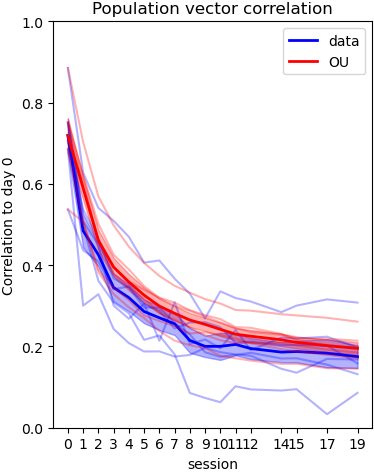

c:\Users\Ole\anaconda3\envs\spyder-env\lib\site-packages\scipy\stats\_morestats.py:1813: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "
c:\Users\Ole\Documents\script\remapping\remapping\statistics_test.py:247: RuntimeWarning: invalid value encountered in scalar divide
  effect_size = np.mean(differences) / np.std(differences, ddof=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,4.014061,16,80,0.250879,131.424789,1.782278e-50,3.867849e-08,0.823764,0.129697
1,condition,0.067251,1,5,0.067251,2.284246,1.910915e-01,1.910915e-01,0.072623,1.000000
2,time * condition,0.023704,16,80,0.001481,2.406996,5.345349e-03,1.139822e-01,0.026860,0.174100


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,NaN,nan,nan,,NaN,Cohen's d,0.7190,0.7190,0.0000,0.0000,6,True,1.0000
1,T2,C1,C2,wilcoxon,0.0000,0.0312,0.5000,,0.8987,r,0.4845,0.5894,-0.1049,0.0540,6,False,0.0215
2,T3,C1,C2,t-test,-1.4709,0.2013,1.0000,,-0.6005,Cohen's d,0.4256,0.4611,-0.0354,0.0590,6,True,0.4476
3,T4,C1,C2,t-test,-2.0490,0.0958,1.0000,,-0.8365,Cohen's d,0.3449,0.3953,-0.0504,0.0603,6,True,0.0903
4,T5,C1,C2,t-test,-1.3079,0.2478,1.0000,,-0.5339,Cohen's d,0.3201,0.3584,-0.0383,0.0717,6,True,0.1300
5,T6,C1,C2,t-test,-1.6207,0.1660,1.0000,,-0.6617,Cohen's d,0.2860,0.3262,-0.0403,0.0608,6,True,0.8528
6,T7,C1,C2,t-test,-1.0106,0.3586,1.0000,,-0.4126,Cohen's d,0.2705,0.2994,-0.0288,0.0698,6,True,0.1599
7,T8,C1,C2,t-test,-1.0743,0.3318,1.0000,,-0.4386,Cohen's d,0.2556,0.2814,-0.0258,0.0589,6,True,0.2515
8,T9,C1,C2,t-test,-1.3950,0.2218,1.0000,,-0.5695,Cohen's d,0.2148,0.2651,-0.0502,0.0882,6,True,0.7169
9,T10,C1,C2,t-test,-1.5706,0.1771,1.0000,,-0.6412,Cohen's d,0.2002,0.2543,-0.0540,0.0842,6,True,0.2262


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,1.976429,16,0.123527,60.322068,8.300126e-38,0.769105,0.144635
1,Error,0.163823,80,0.002048,NaN,NaN,NaN,NaN


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,2.061336,16,0.128833,270.309634,1.288812e-62,0.885927,0.109141
1,Error,0.038129,80,0.000477,NaN,NaN,NaN,NaN


C:\Users\Ole\AppData\Local\Temp\ipykernel_13212\2707443621.py:40: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


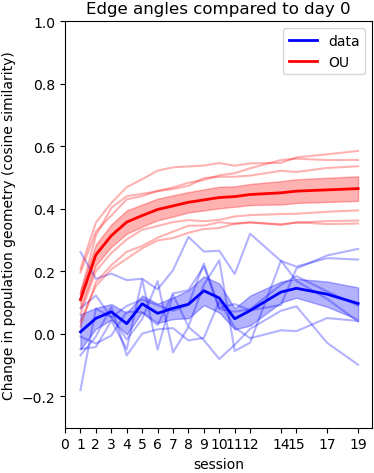

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.722558,15,75,0.048171,18.780943,1.518913e-19,0.000014,0.309237,0.213338
1,condition,4.404750,1,5,4.404750,53.111180,7.611834e-04,0.000761,0.731835,1.000000
2,time * condition,0.223570,15,75,0.014905,5.986561,5.681667e-08,0.004229,0.121665,0.231118


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,-1.7331,0.1436,1.0000,,-0.7075,Cohen's d,0.0066,0.1098,-0.1032,0.1459,6,True,0.5157
1,T2,C1,C2,t-test,-5.1641,0.0036,0.0572,,-2.1082,Cohen's d,0.0499,0.2532,-0.2033,0.0964,6,True,0.6516
2,T3,C1,C2,t-test,-6.9463,0.0009,0.0152,*,-2.8358,Cohen's d,0.0707,0.3144,-0.2437,0.0859,6,True,0.4515
3,T4,C1,C2,t-test,-6.5866,0.0012,0.0194,*,-2.6890,Cohen's d,0.0329,0.3578,-0.3249,0.1208,6,True,0.3268
4,T5,C1,C2,t-test,-9.9526,0.0002,0.0028,**,-4.0631,Cohen's d,0.0965,0.3787,-0.2822,0.0695,6,True,0.4667
5,T6,C1,C2,t-test,-8.4416,0.0004,0.0061,**,-3.4463,Cohen's d,0.0661,0.3982,-0.3321,0.0964,6,True,0.0531
6,T7,C1,C2,t-test,-7.4072,0.0007,0.0113,*,-3.0240,Cohen's d,0.0820,0.4095,-0.3275,0.1083,6,True,0.3497
7,T8,C1,C2,t-test,-7.2037,0.0008,0.0128,*,-2.9409,Cohen's d,0.0949,0.4212,-0.3263,0.1110,6,True,0.2781
8,T9,C1,C2,t-test,-4.8626,0.0046,0.0740,,-1.9851,Cohen's d,0.1382,0.4287,-0.2905,0.1463,6,True,0.5250
9,T10,C1,C2,wilcoxon,0.0000,0.0312,0.5000,,0.8987,r,0.1149,0.4364,-0.3215,0.1294,6,False,0.0009


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.144511,15,0.009634,1.972423,0.028709,0.137982,0.221125
1,Error,0.366330,75,0.004884,NaN,NaN,NaN,NaN


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.801616,15,0.053441,314.06851,3.144669e-61,0.529877,0.191499
1,Error,0.012762,75,0.000170,NaN,NaN,NaN,NaN


In [ ]:
def anova(g, simu_g):
    print_large('\nTWO-WAY REPEATED ANOVA')
    anova=st.repeated_measures_anova_general([np.vstack(g), np.vstack(simu_g)])
    display(anova[0])
    display(anova[1])
    print_large('\nData:')
    display(st.repeated_measures_anova_single_condition(np.vstack(g)))
    print_large('\nRandom Drift:')
    display(st.repeated_measures_anova_single_condition(np.vstack(simu_g)))

x_labels_corr = ['0'] + maps
corr_real = real_pop_correlation                     
corr_sim  = np.vstack(sim_corr_list)                 

fig, ax = plt.subplots(figsize=(4, 5))
plots.plot_average_geometry(
    [corr_real, corr_sim], x_labels_corr,
    colors=['b', 'r'], labels=['data', 'OU'],
    plot_individual=True, ylim=[0, 1], ax=ax
)
ax.set_title('Population vector correlation')
ax.set_ylabel('Correlation to day 0')
fig.tight_layout()
fig.savefig(OUT / "pvc.eps", format="eps")
# fig.savefig(OUT / "pvc.png", dpi=300)
plt.show()
anova(np.vstack(corr_real), np.vstack(corr_sim))

x_labels_geom = maps
fig, ax = plt.subplots(figsize=(4, 5))
plots.plot_average_geometry(
    [forward_data_pop_geometry_angles, sim_geom_list], x_labels_geom,
    colors=['b', 'r'], labels=['data', 'OU'],
    plot_individual=True, ylim=[-0.3, 1], ax=ax
)
ax.set_title('Edge angles compared to day 0')
ax.set_ylabel('Change in population geometry (cosine similarity)')
fig.tight_layout()
fig.savefig(OUT / "geometry.eps", format="eps")
# fig.savefig(OUT / "geometry.png", dpi=300)
plt.show()

anova(np.vstack(forward_data_pop_geometry_angles), np.vstack(sim_geom_list))


In [ ]:
def analyze_data_common(datapath, reference, maps, analysis_type, method='subspace', compute_day11_12=False, 
                        transients=False, dim_red=False, max_dim=4, standardize='stand', bins=60):

    def get_analysis_function(analysis_type):
        if analysis_type == 'population_geometry':
            return analysis.populationgeometry, analysis.populationgeometry_context
        elif analysis_type == 'topology':
            return analysis.topology_analysis, analysis.topology_analysis_context

    analysis_func, context_func = get_analysis_function(analysis_type)

    def apply_analysis(func, *args):
        if analysis_type == 'population_geometry':
            return func(*args, method=method)
        else:
            return func(*args, max_dim=max_dim)

    hists = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference=reference, maps=maps, reference_type='no_reference',
                                                  hist='hist', transients=transients, dim_red=dim_red, 
                                                  standardize=standardize, remove_day_inactive=False, bins=bins)
    g = apply_analysis(analysis_func, hists)

    global_seeds = [1,2,3,4,5]
    simu_g_list = []
    for seed in global_seeds:
        simu_drift = analysis.simulate_drift(datapath, session='0', Context='Context1', days=len(maps)+1, 
                                             drift_type='circular', dim_red=dim_red, standardize=standardize, odd_even=True, 
                                             global_seed=seed, active_days=[reference]+maps, remove_day_inactive=True, 
                                             max_remap_prob=0.3, amplitude_drift_prob=0.3, amplitude_change_scale=0.5, bins=bins)
        simu_g = apply_analysis(analysis_func, simu_drift['maps'])
        simu_g_list.append(simu_g)
    simu_g_array = np.array(simu_g_list)
    simu_g = np.mean(simu_g_array, axis=0)

    hist_odd, hist_even = analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context1', maps=maps, 
                                                                                  transients=transients, dim_red=dim_red,
                                                                                    standardize=standardize, remove_day_inactive=False, bins=bins)
    g_odd_even1 = apply_analysis(context_func, hist_odd, hist_even)

    if analysis_type == 'population_geometry':      
        shuff1, shuff2 = analysis.shuffle_two_sessions_hist(datapath, '0', '19', 'Context1', dim_red=dim_red, remove_inactive=[reference]+maps, 
                                                            standardize=standardize, remove_day_inactive=False, bins=bins)
        g_shuff1 = apply_analysis(context_func, [shuff1], [shuff2])
        
        g = (g - np.mean(g_odd_even1)) / (np.mean(g_shuff1) - np.mean(g_odd_even1))
        simu_g = (simu_g - np.mean(g_odd_even1)) / (np.mean(g_shuff1) - np.mean(g_odd_even1))
  
    return g, simu_g


def collect_data(datapaths, reference, maps, analysis_type, method='subspace', compute_day11_12=False, 
                 transients=False, dim_red=False, max_dim=3, standardize='stand', bins=60):
    all_data = []
    for datapath in datapaths:
        data = analyze_data_common(datapath, reference, maps, analysis_type, method=method, 
                                   compute_day11_12=compute_day11_12, transients=transients, 
                                   dim_red=dim_red, max_dim=max_dim, standardize=standardize, bins=bins)
        all_data.append(data)
    return all_data


datapaths = ['D:/Antje_CA1/data_sig/170.h5', 'D:/Antje_CA1/data_sig/51004.h5', 
                'D:/Antje_CA1/data_sig/51007.h5', 'D:/Antje_CA1/data_sig/63.h5', 
                'D:/Antje_CA1/data_sig/64.h5', 'D:/Antje_CA1/data_sig/65.h5']
transients = False
dim_red = False
max_dim = 4

reference = '0'
maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']

bin_sizes = [10, 20, 40, 80]

all_bin_data = []
all_bin_simu = []

for bins in bin_sizes:
    print(f"Processing bin size: {bins}")
    forward_data_pop_geometry_angles = collect_data(datapaths, reference, maps, 'population_geometry', 
                                                    method='angles', compute_day11_12=False, 
                                                    transients=transients, dim_red=dim_red, 
                                                    standardize='stand', bins=bins)
    
    g_last_day = [data[0][-1] for data in forward_data_pop_geometry_angles] 
    simu_g_last_day = [data[1][-1] for data in forward_data_pop_geometry_angles]
    
    all_bin_data.append(g_last_day)
    all_bin_simu.append(simu_g_last_day)

all_bin_data = np.array(all_bin_data)
all_bin_simu = np.array(all_bin_simu)

all_bin_data = all_bin_data.T
all_bin_simu = all_bin_simu.T

Processing bin size: 10
Processing bin size: 20
Processing bin size: 40
Processing bin size: 80


C:\Users\Ole\AppData\Local\Temp\ipykernel_9380\2850313514.py:12: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


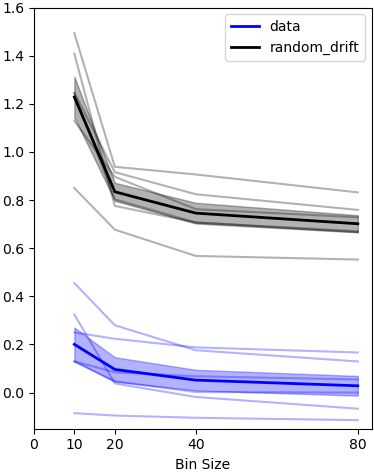

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.898344,3,15,0.299448,73.536664,3.368653e-09,0.000115,0.525007,0.397226
1,condition,7.360058,1,5,7.360058,61.490295,5.413063e-04,0.000541,0.900553,1.000000
2,time * condition,0.245652,3,15,0.081884,10.594386,5.413360e-04,0.020522,0.232094,0.349680


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,T1,C1,C2,t-test,-6.2540,0.0015,0.0061,**,-2.5532,Cohen's d,0.2006,1.2282,-1.0276,0.4025,6,True,0.9558
1,T2,C1,C2,t-test,-8.4699,0.0004,0.0015,**,-3.4578,Cohen's d,0.0963,0.8343,-0.7380,0.2134,6,True,0.9086
2,T3,C1,C2,t-test,-7.9858,0.0005,0.0020,**,-3.2602,Cohen's d,0.0519,0.7457,-0.6938,0.2128,6,True,0.9994
3,T4,C1,C2,t-test,-9.0881,0.0003,0.0011,**,-3.7102,Cohen's d,0.0283,0.7015,-0.6732,0.1815,6,True,0.9727


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.104721,3,0.034907,7.588239,0.002567,0.210225,0.352584
1,Error,0.069002,15,0.004600,NaN,NaN,NaN,NaN


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,1.039275,3,0.346425,48.108384,6.244462e-08,0.712506,0.346318
1,Error,0.108014,15,0.007201,NaN,NaN,NaN,NaN


In [ ]:
print_large('\n' + '='*50)
print_large('RM ANOVA: Edge angles vs Bin Size')
print_large('='*50)
fig, ax = plt.subplots(figsize=(4, 5))

plots.plot_average_geometry([all_bin_data, all_bin_simu], ['10', '20', '40', '80'], colors=['b', 'k'], 
                            labels=['data', 'random_drift'], 
                            plot_individual=True, ylim=[-0.15, 1.6], ax=ax)
ax.set_xlabel('Bin Size')
fig.tight_layout()
fig.savefig(OUT / "edge_angle_vs_bins_size.eps", format="eps")
plt.show()  

print_large('\nTWO-WAY REPEATED ANOVA')
anova = st.repeated_measures_anova_general([all_bin_data, all_bin_simu])
display(anova[0])
display(anova[1])
print_large('\nData:')
display(st.repeated_measures_anova_single_condition(all_bin_data))
print_large('\nRandom Drift:')
display(st.repeated_measures_anova_single_condition(all_bin_simu))